In [2]:
import pdfplumber
import pandas as pd
import os

data_path = r"C:\Users\erikr\Documents\beer-sales-analysis\data\raw"
all_rows = []

for year_folder in os.listdir(data_path):
    year_path = os.path.join(data_path, year_folder)
    if not os.path.isdir(year_path):
        continue
    for pdf_file in os.listdir(year_path):
        if not pdf_file.endswith(".pdf"):
            continue
        pdf_path = os.path.join(year_path, pdf_file)
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                table = page.extract_table()
                if not table:
                    continue
                for row in table[1:]:  # skip header row
                    # skip summary rows (Zwischensumme, Umsatzsteuer, etc.)
                    if row[0] and row[0].strip().isdigit():
                        all_rows.append({
                            "year": year_folder,
                            "source_file": pdf_file,
                            "pos": row[0],
                            "bezeichnung": row[1].replace("\n", " ") if row[1] else None,
                            "menge": row[2],
                            "einheit": row[3],
                            "einzel_eur": row[4],
                            "gesamt_eur": row[5]
                        })

df = pd.DataFrame(all_rows)
print(df.shape)
print(df.head(10))

(8484, 8)
                                                year  \
0  Beleg-Export_von_2019-01-01_bis_2019-12-31_vom...   
1  Beleg-Export_von_2019-01-01_bis_2019-12-31_vom...   
2  Beleg-Export_von_2019-01-01_bis_2019-12-31_vom...   
3  Beleg-Export_von_2019-01-01_bis_2019-12-31_vom...   
4  Beleg-Export_von_2019-01-01_bis_2019-12-31_vom...   
5  Beleg-Export_von_2019-01-01_bis_2019-12-31_vom...   
6  Beleg-Export_von_2019-01-01_bis_2019-12-31_vom...   
7  Beleg-Export_von_2019-01-01_bis_2019-12-31_vom...   
8  Beleg-Export_von_2019-01-01_bis_2019-12-31_vom...   
9  Beleg-Export_von_2019-01-01_bis_2019-12-31_vom...   

                                         source_file pos  \
0  2019-01-10_Einnahme_RE0262_ORA Schmid & Mack G...   1   
1  2019-01-10_Einnahme_RE0263_Caglar & Caglar Bie...   1   
2  2019-01-10_Einnahme_RE0263_Caglar & Caglar Bie...   2   
3  2019-01-10_Einnahme_RE0263_Caglar & Caglar Bie...   3   
4  2019-01-10_Einnahme_RE0263_Caglar & Caglar Bie...   4   
5  2019-01-10

In [4]:
# Fix year column
df["year"] = df["year"].str.extract(r"(\d{4})")

# Fix German number format: remove thousands separator (.) then swap decimal (,) to (.)
def parse_german_float(val):
    if pd.isna(val):
        return None
    val = str(val).strip()
    val = val.replace(".", "").replace(",", ".")
    try:
        return float(val)
    except:
        return None

df["einzel_eur"] = df["einzel_eur"].apply(parse_german_float)
df["gesamt_eur"] = df["gesamt_eur"].apply(parse_german_float)

# Convert menge to integer
df["menge"] = pd.to_numeric(df["menge"], errors="coerce")

print(df.dtypes)
print(df.head(5))

year               str
source_file        str
pos                str
bezeichnung        str
menge          float64
einheit            str
einzel_eur     float64
gesamt_eur     float64
dtype: object
   year                                        source_file pos  \
0  2019  2019-01-10_Einnahme_RE0262_ORA Schmid & Mack G...   1   
1  2019  2019-01-10_Einnahme_RE0263_Caglar & Caglar Bie...   1   
2  2019  2019-01-10_Einnahme_RE0263_Caglar & Caglar Bie...   2   
3  2019  2019-01-10_Einnahme_RE0263_Caglar & Caglar Bie...   3   
4  2019  2019-01-10_Einnahme_RE0263_Caglar & Caglar Bie...   4   

                                         bezeichnung  menge einheit  \
0  Marlene, traditionelle Berliner Weisse Karton,...   10.0   Stück   
1  Marlene, traditionelle Berliner Weisse Karton,...   15.0   Stück   
2  Kennedy, Berliner Weisse mit Hopfen Karton 12 ...    5.0   Stück   
3  Irmgard, GingerAle Berliner Weisse Style Karto...    5.0   Stück   
4  Bruno - Woody & Bretted Karton 12 Flaschen 0,3.

In [5]:
# 1. Total revenue by year
revenue_by_year = df.groupby("year")["gesamt_eur"].sum().reset_index()
revenue_by_year.columns = ["year", "total_revenue_eur"]
print("=== Revenue by Year ===")
print(revenue_by_year.to_string(index=False))

# 2. Top 10 best selling products (by total revenue)
top_products = df.groupby("bezeichnung")["gesamt_eur"].sum().sort_values(ascending=False).head(10).reset_index()
top_products.columns = ["product", "total_revenue_eur"]
print("\n=== Top 10 Products by Revenue ===")
print(top_products.to_string(index=False))

# 3. Top 10 customers by revenue (extracted from filename)
df["customer"] = df["source_file"].str.extract(r"RE\d+_(.*?)\.pdf")
top_customers = df.groupby("customer")["gesamt_eur"].sum().sort_values(ascending=False).head(10).reset_index()
top_customers.columns = ["customer", "total_revenue_eur"]
print("\n=== Top 10 Customers by Revenue ===")
print(top_customers.to_string(index=False))

=== Revenue by Year ===
year  total_revenue_eur
2019           92498.64
2020           83014.88
2021          178419.75
2022          213290.26
2023          112931.85
2024           64601.18
2025           46662.39

=== Top 10 Products by Revenue ===
                                                                                                product  total_revenue_eur
       10121 Marlene - original Berliner Weisse Karton mit 12 Flaschen 0,33l Retail, 8° Plato, 3,5% ABV            24176.8
       10123 Marlene - original Berliner Weisse Karton mit 12 Flaschen 0,33l Export, 8° Plato, 3,5% ABV            22258.8
                         10143 Marlene - original Berliner Weisse Keykeg 30l Export, 8° Plato, 3,5% ABV            18081.0
                                                                                       12 Pack gemischt            17223.0
       10223 Kennedy - gehopfte Berliner Weisse Karton mit 12 Flaschen 0,33l Export, 8° Plato, 3,5% ABV            14461.8
       102

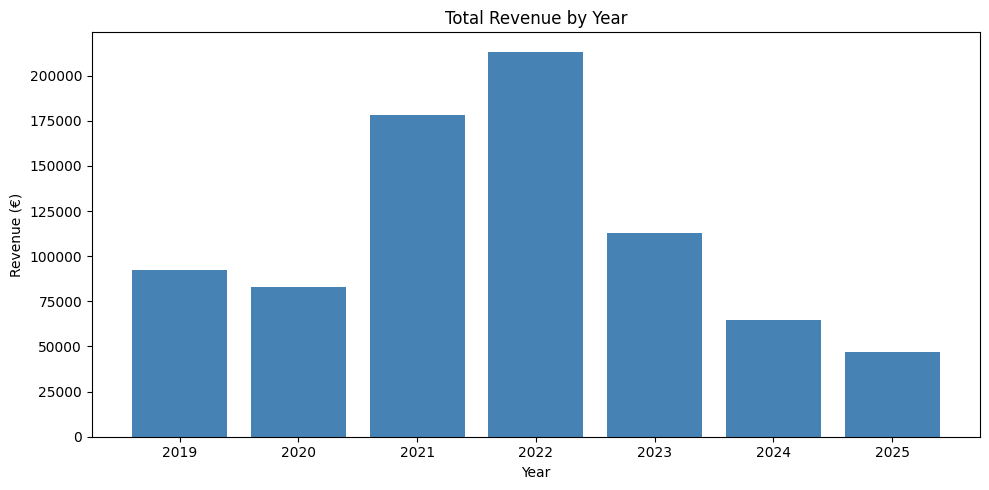

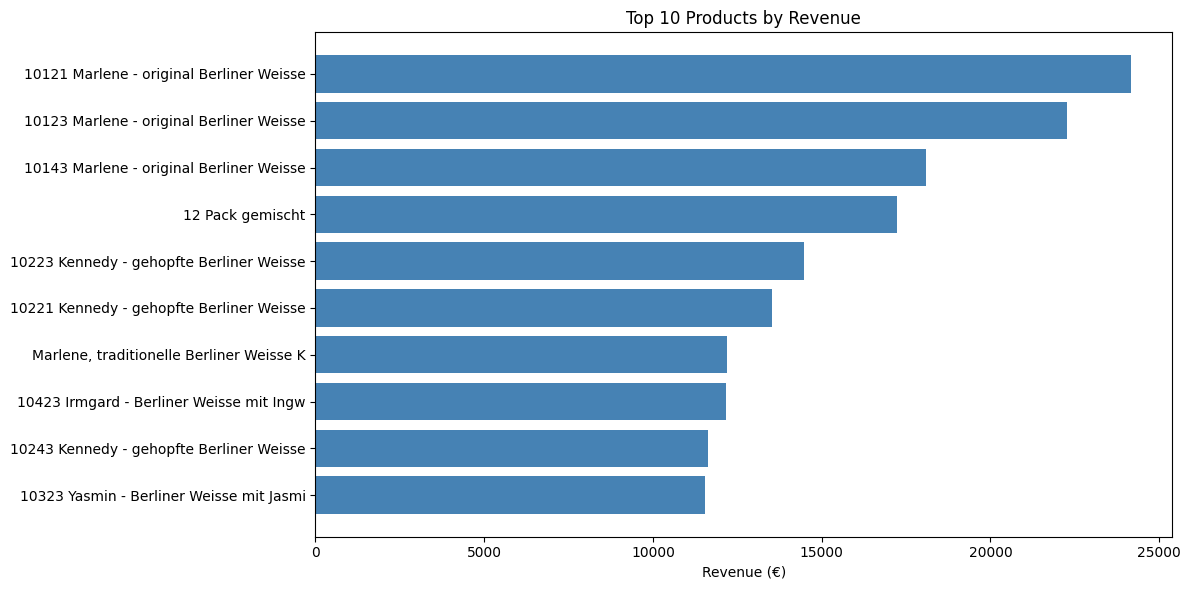

Saved to output folder!


In [6]:
import matplotlib.pyplot as plt

# Save tables to Excel
output_path = r"C:\Users\erikr\Documents\beer-sales-analysis\output"

with pd.ExcelWriter(os.path.join(output_path, "beer_sales_summary.xlsx")) as writer:
    revenue_by_year.to_excel(writer, sheet_name="Revenue by Year", index=False)
    top_products.to_excel(writer, sheet_name="Top Products", index=False)
    top_customers.to_excel(writer, sheet_name="Top Customers", index=False)
    df.to_excel(writer, sheet_name="Raw Data", index=False)

# Chart 1: Revenue by year
plt.figure(figsize=(10, 5))
plt.bar(revenue_by_year["year"], revenue_by_year["total_revenue_eur"], color="steelblue")
plt.title("Total Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue (€)")
plt.tight_layout()
plt.savefig(os.path.join(output_path, "revenue_by_year.png"))
plt.show()

# Chart 2: Top 10 products
plt.figure(figsize=(12, 6))
plt.barh(top_products["product"].str[:40], top_products["total_revenue_eur"], color="steelblue")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (€)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(output_path, "top_products.png"))
plt.show()

print("Saved to output folder!")

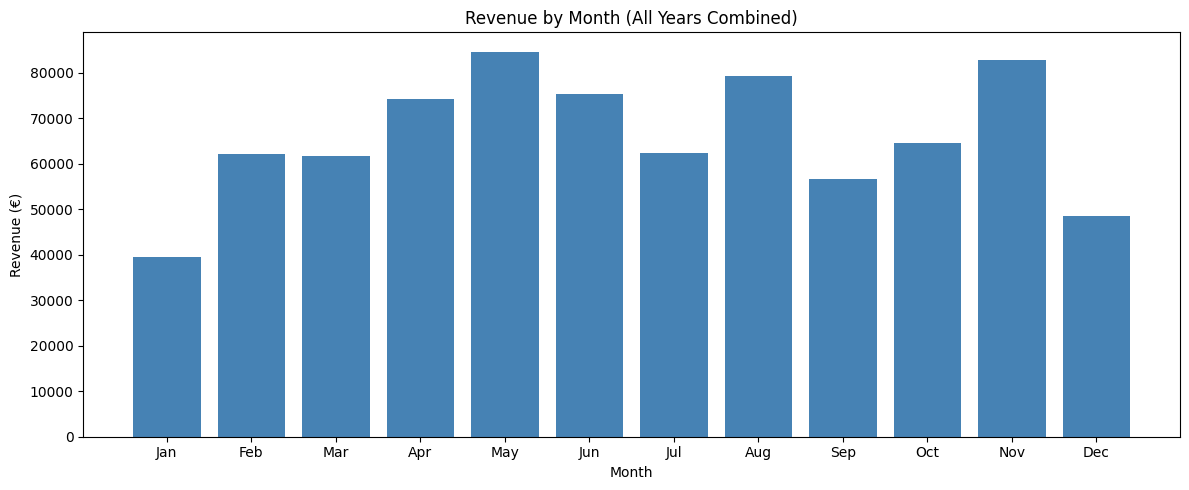

=== Customer Retention ===
 years_active  customer_count
            1             146
            2              46
            3              27
            4              10
            5               9
            6               7
            7               6

Customers active 4+ years: 32
                     customer  years_active
BRLO Gastronomie Holding GmbH             7
                    Bierladen             7
              Billy Wagner KG             7
                         CODA             7
                  Sammelkunde             7
              Hopfenreich OHG             7
                  BoxHag GmbH             6
               Bierothek GmbH             6
                   Krüger Eck             6
              MUTED HORN GMBH             6
      G&H Getränkekontor GmbH             6
              Philip Arhelger             6
          BRÄUGIER Craft GmbH             6
              Flaneur Liquids             5
            Craftbeer-Shopcom             

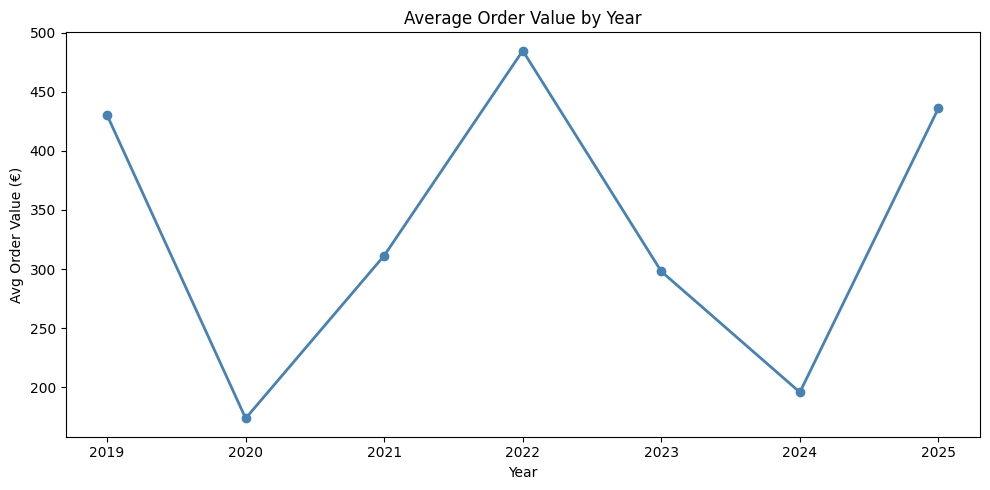

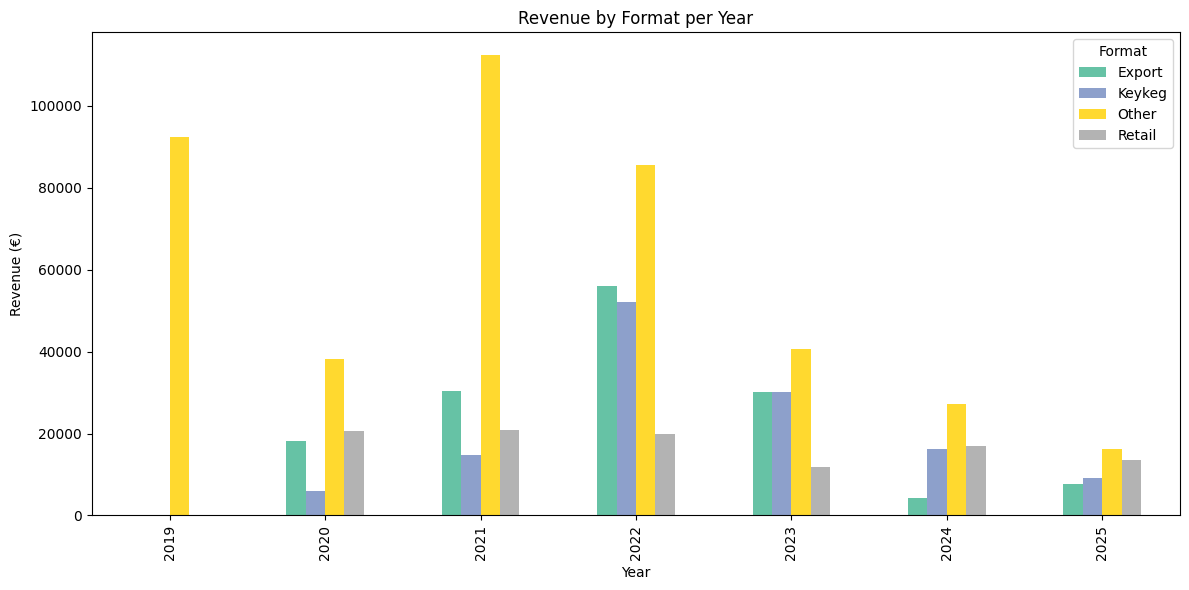

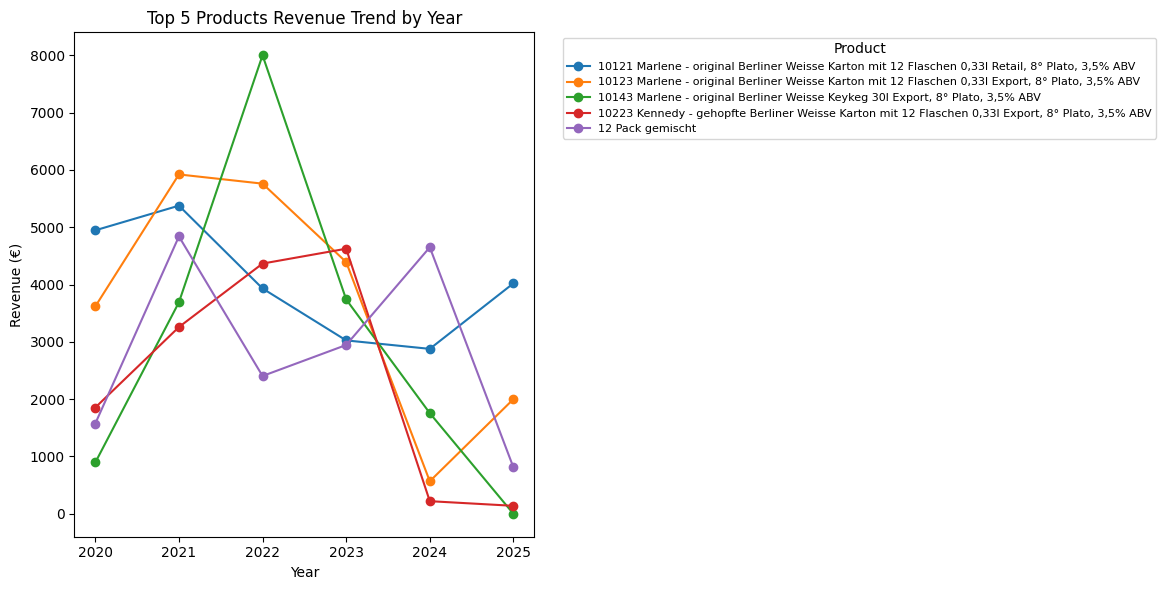


=== Top 5 Customers Per Year ===
year                      customer  gesamt_eur
2019                 One Pint GmbH    15052.50
2019              Shelton Brothers     6950.00
2019       FBC Business Consulting     5997.84
2019                MarketBeer Ltd     5666.22
2019             Derer Import GmbH     4064.40
2020                   Sammelkunde    21742.51
2020     Brausturm Bierverlag GmbH     6807.60
2020                   Gobsmack BV     4158.00
2020                Bierothek GmbH     3528.60
2020        UAB Kraustykis lengvai     3436.00
2021                   Sammelkunde    18776.27
2021                Bierothek GmbH    11254.00
2021               Flaneur Liquids    10008.20
2021                   Gobsmack BV     9387.20
2021                 Brill & Co AB     5577.60
2022             Lime Ventures Inc    21216.00
2022                   Sammelkunde    18200.99
2022                BAKU-YAism LLC    15548.00
2022                 Urstoff V O F    13348.20
2022 Shanghai DaoLi Tradin

In [7]:
# FULL ANALYSIS - Beer Sales Intelligence

# --- Extract date and customer from filename ---
df["date"] = pd.to_datetime(df["source_file"].str.extract(r"(\d{4}-\d{2}-\d{2})")[0], errors="coerce")
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["customer"] = df["source_file"].str.extract(r"RE\d+_(.*?)\.pdf")

# --- Extract format type from product name ---
df["format"] = "Other"
df.loc[df["bezeichnung"].str.contains("Retail", na=False), "format"] = "Retail"
df.loc[df["bezeichnung"].str.contains("Export", na=False), "format"] = "Export"
df.loc[df["bezeichnung"].str.contains("Keykeg", na=False), "format"] = "Keykeg"


# 1. MONTHLY SEASONALITY

seasonality = df.groupby(["month", "month_name"])["gesamt_eur"].sum().reset_index()
seasonality = seasonality.sort_values("month")

plt.figure(figsize=(12, 5))
plt.bar(seasonality["month_name"], seasonality["gesamt_eur"], color="steelblue")
plt.title("Revenue by Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Revenue (€)")
plt.tight_layout()
plt.savefig(os.path.join(output_path, "seasonality.png"))
plt.show()


# 2. CUSTOMER RETENTION (yearly unique customers)

customer_years = df.groupby("customer")["year"].nunique().reset_index()
customer_years.columns = ["customer", "years_active"]

retention_summary = customer_years["years_active"].value_counts().sort_index().reset_index()
retention_summary.columns = ["years_active", "customer_count"]
print("=== Customer Retention ===")
print(retention_summary.to_string(index=False))

loyal_customers = customer_years[customer_years["years_active"] >= 4].sort_values("years_active", ascending=False)
print(f"\nCustomers active 4+ years: {len(loyal_customers)}")
print(loyal_customers.to_string(index=False))


# 3. AVERAGE ORDER VALUE BY YEAR

aov = df.groupby(["year", "source_file"])["gesamt_eur"].sum().reset_index()
aov = aov.groupby("year")["gesamt_eur"].mean().reset_index()
aov.columns = ["year", "avg_order_value"]

plt.figure(figsize=(10, 5))
plt.plot(aov["year"], aov["avg_order_value"], marker="o", color="steelblue", linewidth=2)
plt.title("Average Order Value by Year")
plt.xlabel("Year")
plt.ylabel("Avg Order Value (€)")
plt.tight_layout()
plt.savefig(os.path.join(output_path, "avg_order_value.png"))
plt.show()


# 4. RETAIL VS EXPORT VS KEYKEG BY YEAR

format_mix = df.groupby(["year", "format"])["gesamt_eur"].sum().unstack(fill_value=0)

format_mix.plot(kind="bar", figsize=(12, 6), colormap="Set2")
plt.title("Revenue by Format per Year")
plt.xlabel("Year")
plt.ylabel("Revenue (€)")
plt.legend(title="Format")
plt.tight_layout()
plt.savefig(os.path.join(output_path, "format_mix.png"))
plt.show()


# 5. TOP PRODUCT TRENDS BY YEAR

top_product_names = top_products["product"].head(5).tolist()
product_trend = df[df["bezeichnung"].isin(top_product_names)].groupby(["year", "bezeichnung"])["gesamt_eur"].sum().unstack(fill_value=0)

product_trend.plot(figsize=(12, 6), marker="o")
plt.title("Top 5 Products Revenue Trend by Year")
plt.xlabel("Year")
plt.ylabel("Revenue (€)")
plt.legend(title="Product", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(output_path, "product_trends.png"))
plt.show()


# 6. TOP CUSTOMERS PER YEAR (did big ones disappear?)

top_customers_per_year = df.groupby(["year", "customer"])["gesamt_eur"].sum().reset_index()
top_per_year = top_customers_per_year.sort_values(["year", "gesamt_eur"], ascending=[True, False])
top_per_year = top_per_year.groupby("year").head(5)
print("\n=== Top 5 Customers Per Year ===")
print(top_per_year.to_string(index=False))


# SAVE ALL TO EXCEL

with pd.ExcelWriter(os.path.join(output_path, "beer_sales_summary.xlsx")) as writer:
    revenue_by_year.to_excel(writer, sheet_name="Revenue by Year", index=False)
    top_products.to_excel(writer, sheet_name="Top Products", index=False)
    top_customers.to_excel(writer, sheet_name="Top Customers", index=False)
    seasonality.to_excel(writer, sheet_name="Seasonality", index=False)
    retention_summary.to_excel(writer, sheet_name="Customer Retention", index=False)
    aov.to_excel(writer, sheet_name="Avg Order Value", index=False)
    format_mix.to_excel(writer, sheet_name="Format Mix")
    top_per_year.to_excel(writer, sheet_name="Top Customers Per Year", index=False)
    df.to_excel(writer, sheet_name="Raw Data", index=False)

print("\nAll saved to output folder!")

In [8]:
test_pdf = r"C:\Users\erikr\Documents\beer-sales-analysis\data\raw\2019\2019-01-10_Einnahme_RE0263_Caglar & Caglar Bie...pdf"

with pdfplumber.open(test_pdf) as pdf:
    for page in pdf.pages:
        print(page.extract_text())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\erikr\\Documents\\beer-sales-analysis\\data\\raw\\2019\\2019-01-10_Einnahme_RE0263_Caglar & Caglar Bie...pdf'

In [10]:
folder = r"C:\Users\erikr\Documents\beer-sales-analysis\data\raw"
for f in os.listdir(folder):
    print(f)

Beleg-Export_von_2019-01-01_bis_2019-12-31_vom_2026-02-20_134320
Beleg-Export_von_2020-01-01_bis_2020-12-31_vom_2026-02-20_134312
Beleg-Export_von_2021-01-01_bis_2021-12-31_vom_2026-02-20_134302
Beleg-Export_von_2022-01-01_bis_2022-12-31_vom_2026-02-20_135628
Beleg-Export_von_2023-01-01_bis_2023-12-31_vom_2026-02-20_135203
Beleg-Export_von_2024-01-01_bis_2024-12-31_vom_2026-02-20_134639
Beleg-Export_von_2025-01-01_bis_2025-12-31_vom_2026-02-20_134650


In [11]:
import os

folder = r"C:\Users\erikr\Documents\beer-sales-analysis\data\raw\Beleg-Export_von_2019-01-01_bis_2019-12-31_vom_2026-02-20_134320"

# Get first PDF in the folder
first_pdf = os.path.join(folder, os.listdir(folder)[0])
print("Opening:", first_pdf)

with pdfplumber.open(first_pdf) as pdf:
    for page in pdf.pages:
        print(page.extract_text())

Opening: C:\Users\erikr\Documents\beer-sales-analysis\data\raw\Beleg-Export_von_2019-01-01_bis_2019-12-31_vom_2026-02-20_134320\2019-01-10_Einnahme_RE0262_ORA Schmid & Mack GmbH.pdf
Rechnung
Rechnungsnr.: RE0262
Kundennr.: 10069
Datum: 10.01.2019
Lieferdatum: 10.01.2019
Schneeeule Brauerei GmbH
Schneeeule Brauerei GmbH, Edinburger Str, 59, 13349 Berlin
Edinburger Str, 59
ORA Schmid & Mack GmbH 13349 Berlin
Oranienplatz 14 Tel.: 017623229336
10999 Berlin
ulrike.genz@Schneeeule.berlin
www.schneeeule.berlin
Unsere Lieferungen/Leistungen stellen wir Ihnen wie folgt in Rechnung.
Pos. Bezeichnung Menge Einheit Einzel € Gesamt €
1 Marlene, traditionelle Berliner Weisse 10 Stück 21,60 216,00
Karton, 12 Flaschen 0,33, 8° Plato, 3 % ABV
Zwischensumme (netto) 216,00
Umsatzsteuer 19 % 41,04
Gesamtbetrag 257,04
Zahlbar sofort, rein netto
Vielen Dank für die gute Zusammenarbeit.
Schneeeule Brauerei GmbH USt-IdNr.: DE313860873 Schneeeule Brauerei GmbH
Edinburger Str, 59 Amtsgericht Charlottenburg Lan

In [12]:
import re

def extract_customer_address(pdf_path):
    with pdfplumber.open(pdf_path) as pdf:
        text = pdf.pages[0].extract_text()
    
    # Find postal code + city line (German format: 5 digits + city)
    match = re.search(r"(\d{5})\s+([A-Za-zÄäÖöÜüß\s\-]+)\n([A-Za-z]+)?", text)
    city = match.group(2).strip() if match else None
    country = match.group(3).strip() if match and match.group(3) else "Germany"
    
    return city, country

# Test on first PDF
city, country = extract_customer_address(first_pdf)
print(f"City: {city}, Country: {country}")

City: Berlin, Country: Edinburger


In [13]:
def extract_customer_address(pdf_path):
    with pdfplumber.open(pdf_path) as pdf:
        text = pdf.pages[0].extract_text()
    
    # Find ALL postal code + city matches, take the second one (customer, not brewery)
    matches = re.findall(r"(\d{5})\s+([A-Za-zÄäÖöÜüß\s\-]+?)(?:\n|$)", text)
    
    if len(matches) >= 2:
        city = matches[1][1].strip()  # second match = customer
        country = "Germany"  # default for German postal codes
    elif len(matches) == 1:
        city = matches[0][1].strip()
        country = "Germany"
    else:
        # Non-German postal format = likely international
        city = None
        country = "Unknown"
    
    return city, country

city, country = extract_customer_address(first_pdf)
print(f"City: {city}, Country: {country}")

City: Berlin, Country: Germany


In [14]:
# Build a lookup dictionary: source_file -> (city, country)
address_lookup = {}

for year_folder in os.listdir(data_path):
    year_path = os.path.join(data_path, year_folder)
    if not os.path.isdir(year_path):
        continue
    for pdf_file in os.listdir(year_path):
        if not pdf_file.endswith(".pdf"):
            continue
        pdf_path = os.path.join(year_path, pdf_file)
        try:
            city, country = extract_customer_address(pdf_path)
            address_lookup[pdf_file] = (city, country)
        except:
            address_lookup[pdf_file] = (None, "Unknown")

# Map back to dataframe
df["city"] = df["source_file"].map(lambda x: address_lookup.get(x, (None, None))[0])
df["country"] = df["source_file"].map(lambda x: address_lookup.get(x, (None, "Unknown"))[1])

print(f"Extracted addresses for {len(address_lookup)} invoices")
print(df[["source_file", "city", "country"]].drop_duplicates().head(10))

Extracted addresses for 2522 invoices
                                          source_file    city  country
0   2019-01-10_Einnahme_RE0262_ORA Schmid & Mack G...  Berlin  Germany
1   2019-01-10_Einnahme_RE0263_Caglar & Caglar Bie...  Berlin  Germany
5   2019-01-10_Einnahme_RE0264_Caglar & Caglar Bie...  Berlin  Germany
6      2019-01-10_Einnahme_RE0265_Philip Arhelger.pdf  Berlin  Germany
12     2019-01-11_Einnahme_RE0266_Tante Frizzante.pdf  Berlin  Germany
16          2019-01-16_Einnahme_RE0267_IHK Berlin.pdf  Berlin  Germany
19     2019-02-02_Einnahme_RE0268_Beerellion GmbH.pdf  Berlin  Germany
24  2019-02-02_Einnahme_RE0270_Belgium Craftbeer C...  Berlin  Germany
29   2019-02-08_Einnahme_RE0271_Derer Import GmbH.pdf  Berlin  Germany
34      2019-02-09_Einnahme_RE0278_Thomsen-Wiebke.pdf  Berlin  Germany


In [15]:
# Check country distribution
country_distribution = df[["source_file", "city", "country"]].drop_duplicates()
print("=== Country Distribution ===")
print(country_distribution["country"].value_counts())

print("\n=== Sample Unknown entries ===")
unknown = country_distribution[country_distribution["country"] == "Unknown"]
print(unknown.head(10))

=== Country Distribution ===
country
Germany    2522
Name: count, dtype: int64

=== Sample Unknown entries ===
Empty DataFrame
Columns: [source_file, city, country]
Index: []


In [16]:
# City breakdown by revenue
city_revenue = df.groupby("city")["gesamt_eur"].sum().sort_values(ascending=False).reset_index()
city_revenue.columns = ["city", "total_revenue_eur"]
print("=== Revenue by City ===")
print(city_revenue.to_string(index=False))

=== Revenue by City ===
  city  total_revenue_eur
Berlin          791418.95


In [19]:
def extract_customer_address_v2(pdf_path):
    with pdfplumber.open(pdf_path) as pdf:
        text = pdf.pages[0].extract_text()
    
    lines = text.split("\n")
    
    # Print all lines so we can see the structure
    for i, line in enumerate(lines):
        print(f"Line {i}: {line}")

extract_customer_address_v2(first_pdf)

Line 0: Rechnung
Line 1: Rechnungsnr.: RE0262
Line 2: Kundennr.: 10069
Line 3: Datum: 10.01.2019
Line 4: Lieferdatum: 10.01.2019
Line 5: Schneeeule Brauerei GmbH
Line 6: Schneeeule Brauerei GmbH, Edinburger Str, 59, 13349 Berlin
Line 7: Edinburger Str, 59
Line 8: ORA Schmid & Mack GmbH 13349 Berlin
Line 9: Oranienplatz 14 Tel.: 017623229336
Line 10: 10999 Berlin
Line 11: ulrike.genz@Schneeeule.berlin
Line 12: www.schneeeule.berlin
Line 13: Unsere Lieferungen/Leistungen stellen wir Ihnen wie folgt in Rechnung.
Line 14: Pos. Bezeichnung Menge Einheit Einzel € Gesamt €
Line 15: 1 Marlene, traditionelle Berliner Weisse 10 Stück 21,60 216,00
Line 16: Karton, 12 Flaschen 0,33, 8° Plato, 3 % ABV
Line 17: Zwischensumme (netto) 216,00
Line 18: Umsatzsteuer 19 % 41,04
Line 19: Gesamtbetrag 257,04
Line 20: Zahlbar sofort, rein netto
Line 21: Vielen Dank für die gute Zusammenarbeit.
Line 22: Schneeeule Brauerei GmbH USt-IdNr.: DE313860873 Schneeeule Brauerei GmbH
Line 23: Edinburger Str, 59 Amtsge

In [20]:
def extract_customer_address_v3(pdf_path):
    with pdfplumber.open(pdf_path) as pdf:
        text = pdf.pages[0].extract_text()
    
    lines = text.split("\n")
    
    city = None
    country = "Germany"  # default for German postal codes
    
    for i, line in enumerate(lines):
        # Skip any Schneeeule brewery lines
        if any(x in line for x in ["Schneeeule", "Edinburger", "ulrike", "www."]):
            continue
        # Match customer postal line: 4-5 digit postal code + city
        match = re.match(r"^(\d{4,5})\s+([A-Za-zÄäÖöÜüß\s\-]+)$", line.strip())
        if match:
            city = match.group(2).strip()
            # Check next line for country name
            if i + 1 < len(lines):
                next_line = lines[i + 1].strip()
                if next_line and not any(char.isdigit() for char in next_line) and len(next_line) < 30 and "Schneeeule" not in next_line:
                    country = next_line
            break
    
    return city, country

# Test on first PDF
city, country = extract_customer_address_v3(first_pdf)
print(f"City: {city}, Country: {country}")

# Test on an international-looking invoice
belgium_pdf = os.path.join(data_path, "Beleg-Export_von_2019-01-01_bis_2019-12-31_vom_2026-02-20_134320", 
              "2019-02-02_Einnahme_RE0270_Belgium Craftbeer C...pdf")
# First let's find the full filename
for f in os.listdir(os.path.join(data_path, "Beleg-Export_von_2019-01-01_bis_2019-12-31_vom_2026-02-20_134320")):
    if "Belgium" in f:
        print(f)

City: Berlin, Country: Germany
2019-02-02_Einnahme_RE0270_Belgium Craftbeer Company.pdf
2019-02-28_Einnahme_RE0280_Belgium Craftbeer Company.pdf


In [21]:
belgium_pdf = os.path.join(data_path, 
              "Beleg-Export_von_2019-01-01_bis_2019-12-31_vom_2026-02-20_134320", 
              "2019-02-02_Einnahme_RE0270_Belgium Craftbeer Company.pdf")

# First print all lines to see the address structure
with pdfplumber.open(belgium_pdf) as pdf:
    text = pdf.pages[0].extract_text()

for i, line in enumerate(text.split("\n")):
    print(f"Line {i}: {line}")

Line 0: Invoice
Line 1: Invoice no.: RE0270
Line 2: Customer no.: 10101
Line 3: Date: 02.02.2019
Line 4: Delivery date: 02.02.2019
Line 5: Schneeeule Brauerei GmbH
Line 6: Schneeeule Brauerei GmbH, Edinburger Str, 59, 13349 Berlin
Line 7: Edinburger Str, 59
Line 8: Belgium Craftbeer Company 13349 Berlin
Line 9: BE 0818732656 Phone: 017623229336
Line 10: Heirbaan 121
Line 11: ulrike.genz@Schneeeule.berlin
Line 12: 2070 Burcht
Line 13: www.schneeeule.berlin
Line 14: Belgium
Line 15: For our deliveries/services we kindly request the following payment.
Line 16: Item Description Quantity Unit Price € Amount €
Line 17: 1 Marlene, , traditionelle Berliner Weisse 1 Stück 85,00 85,00
Line 18: Keg 30 Liter , 8° Plato, 3 % ABV
Line 19: 2 Marlene, traditionelle Berliner Weisse 2 Stück 18,00 36,00
Line 20: Karton, 12 Flaschen 0,33, 8° Plato, 3 % ABV
Line 21: 3 Irmgard, GingerAle Berliner Weisse Style 2 Stück 18,00 36,00
Line 22: Karton, 12 Flaschen 0,33 Liter, 8° Plato, 3 %
Line 23: ABV
Line 24: 4 

In [22]:
def extract_customer_address_v4(pdf_path):
    with pdfplumber.open(pdf_path) as pdf:
        text = pdf.pages[0].extract_text()
    
    lines = text.split("\n")
    
    city = None
    country = "Germany"  # default
    
    for i, line in enumerate(lines):
        # Skip Schneeeule brewery lines
        if any(x in line for x in ["Schneeeule", "Edinburger", "ulrike", "www."]):
            continue
        # Match 4 or 5 digit postal code + city
        match = re.match(r"^(\d{4,5})\s+([A-Za-zÄäÖöÜüß\s\-]+)$", line.strip())
        if match:
            city = match.group(2).strip()
            # Check next non-empty line for country
            if i + 1 < len(lines):
                next_line = lines[i + 1].strip()
                if (next_line 
                    and not any(char.isdigit() for char in next_line) 
                    and len(next_line) < 30 
                    and not any(x in next_line for x in ["Schneeeule", "ulrike", "www.", "Tel", "For our", "Unsere"])):
                    country = next_line
            break
    
    return city, country

# Test on both invoices
city, country = extract_customer_address_v4(first_pdf)
print(f"German invoice - City: {city}, Country: {country}")

city, country = extract_customer_address_v4(belgium_pdf)
print(f"Belgium invoice - City: {city}, Country: {country}")

German invoice - City: Berlin, Country: Germany
Belgium invoice - City: Burcht, Country: Germany


In [23]:
def extract_customer_address_v5(pdf_path):
    with pdfplumber.open(pdf_path) as pdf:
        text = pdf.pages[0].extract_text()
    
    lines = text.split("\n")
    
    city = None
    country = "Germany"  # default
    
    skip_keywords = ["Schneeeule", "Edinburger", "ulrike", "www.", "Tel", 
                     "For our", "Unsere", "Phone", "Telefon"]
    
    for i, line in enumerate(lines):
        if any(x in line for x in skip_keywords):
            continue
        # Match 4 or 5 digit postal code + city
        match = re.match(r"^(\d{4,5})\s+([A-Za-zÄäÖöÜüß\s\-]+)$", line.strip())
        if match:
            city = match.group(2).strip()
            # Look ahead up to 3 lines for a country name (skipping brewery lines)
            for j in range(i + 1, min(i + 4, len(lines))):
                next_line = lines[j].strip()
                if any(x in next_line for x in skip_keywords):
                    continue
                if (next_line 
                    and not any(char.isdigit() for char in next_line) 
                    and len(next_line) < 30):
                    country = next_line
                    break
            break
    
    return city, country

# Test on both
city, country = extract_customer_address_v5(first_pdf)
print(f"German invoice - City: {city}, Country: {country}")

city, country = extract_customer_address_v5(belgium_pdf)
print(f"Belgium invoice - City: {city}, Country: {country}")

German invoice - City: Berlin, Country: Germany
Belgium invoice - City: Burcht, Country: Belgium


In [24]:
# Rebuild address lookup with v5
address_lookup_v5 = {}

for year_folder in os.listdir(data_path):
    year_path = os.path.join(data_path, year_folder)
    if not os.path.isdir(year_path):
        continue
    for pdf_file in os.listdir(year_path):
        if not pdf_file.endswith(".pdf"):
            continue
        pdf_path = os.path.join(year_path, pdf_file)
        try:
            city, country = extract_customer_address_v5(pdf_path)
            address_lookup_v5[pdf_file] = (city, country)
        except:
            address_lookup_v5[pdf_file] = (None, "Unknown")

# Update dataframe
df["city"] = df["source_file"].map(lambda x: address_lookup_v5.get(x, (None, None))[0])
df["country"] = df["source_file"].map(lambda x: address_lookup_v5.get(x, (None, "Unknown"))[1])

# Show country distribution
print("=== Country Distribution ===")
print(df[["source_file", "country"]].drop_duplicates()["country"].value_counts())

=== Country Distribution ===
country
Germany                      1131
Schweiz                        16
Belgien                        13
Dänemark                       12
Österreich                     10
                             ... 
Hallo Sarina Lindtner,          1
Hallo Sebastian Sobottka,       1
Hallo Gregor Raab,              1
Hallo Jakob Heinrich,           1
Hallo Thomas Bergemann,         1
Name: count, Length: 1031, dtype: int64


In [25]:
# Known valid countries to keep
valid_countries = [
    "Germany", "Deutschland", "Schweiz", "Switzerland", "Belgien", "Belgium",
    "Dänemark", "Denmark", "Österreich", "Austria", "Netherlands", "Niederlande",
    "France", "Frankreich", "UK", "United Kingdom", "Sweden", "Schweden",
    "Norway", "Norwegen", "Finland", "Finnland", "Poland", "Polen",
    "Spain", "Spanien", "Italy", "Italien", "USA", "United States",
    "China", "Japan", "Australia", "Canada", "Lithuania", "Litauen"
]

# Normalize country names to English
country_map = {
    "Deutschland": "Germany", "Schweiz": "Switzerland", "Belgien": "Belgium",
    "Dänemark": "Denmark", "Österreich": "Austria", "Niederlande": "Netherlands",
    "Frankreich": "France", "Schweden": "Sweden", "Norwegen": "Norway",
    "Finnland": "Finland", "Polen": "Poland", "Spanien": "Spain",
    "Italien": "Italy", "Litauen": "Lithuania"
}

# Apply filter and normalization
df["country_clean"] = df["country"].apply(lambda x: x if x in valid_countries else None)
df["country_clean"] = df["country_clean"].map(lambda x: country_map.get(x, x))

# Revenue by country
country_revenue = df.groupby("country_clean")["gesamt_eur"].sum().sort_values(ascending=False).reset_index()
country_revenue.columns = ["country", "total_revenue_eur"]
print("=== Revenue by Country ===")
print(country_revenue.dropna().to_string(index=False))

=== Revenue by Country ===
    country  total_revenue_eur
    Germany          552074.66
    Belgium           29282.47
    Denmark           28901.45
     France           13727.56
      Italy           13660.95
Switzerland           12529.33
     Norway           12089.80
    Finland           12068.63
Netherlands           10456.31
  Lithuania            5907.00
      Spain            2540.81
    Austria             917.30
     Sweden             664.80


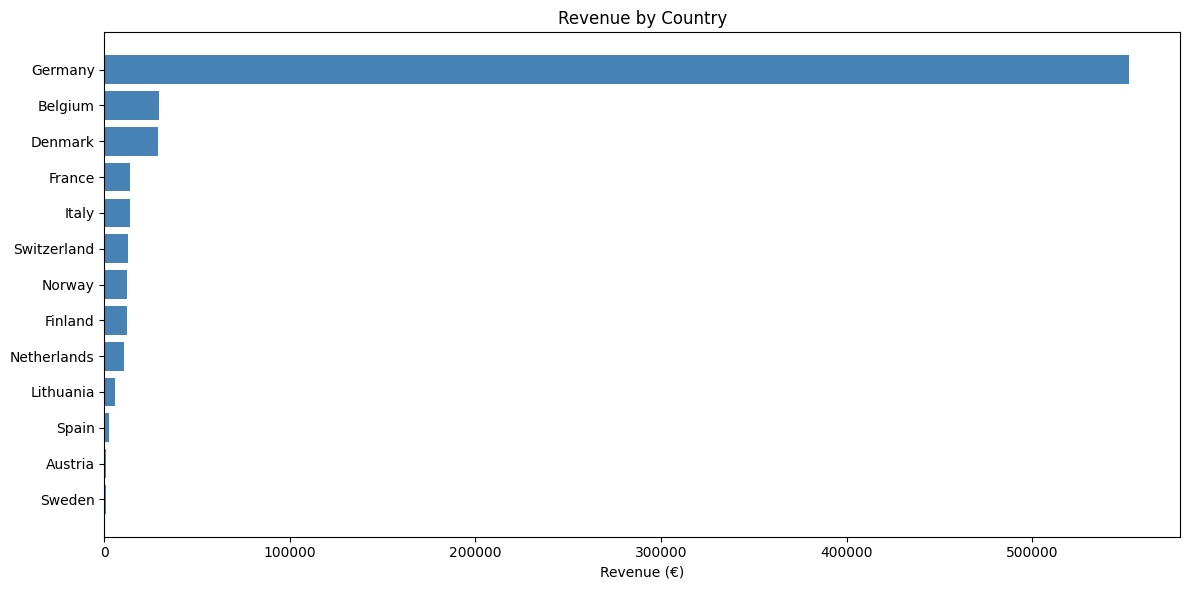

Saved!


In [26]:
# Chart - Revenue by Country
country_data = country_revenue.dropna()

plt.figure(figsize=(12, 6))
plt.barh(country_data["country"], country_data["total_revenue_eur"], color="steelblue")
plt.title("Revenue by Country")
plt.xlabel("Revenue (€)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(output_path, "revenue_by_country.png"))
plt.show()

# Update Excel with country tab
with pd.ExcelWriter(os.path.join(output_path, "beer_sales_summary.xlsx")) as writer:
    revenue_by_year.to_excel(writer, sheet_name="Revenue by Year", index=False)
    top_products.to_excel(writer, sheet_name="Top Products", index=False)
    top_customers.to_excel(writer, sheet_name="Top Customers", index=False)
    seasonality.to_excel(writer, sheet_name="Seasonality", index=False)
    retention_summary.to_excel(writer, sheet_name="Customer Retention", index=False)
    aov.to_excel(writer, sheet_name="Avg Order Value", index=False)
    format_mix.to_excel(writer, sheet_name="Format Mix")
    top_per_year.to_excel(writer, sheet_name="Top Customers Per Year", index=False)
    country_data.to_excel(writer, sheet_name="Revenue by Country", index=False)
    df.to_excel(writer, sheet_name="Raw Data", index=False)

print("Saved!")

    beer  untappd_rating  untappd_checkins  total_revenue_eur
 Marlene            3.54            8036.0          150101.64
 Kennedy            3.56            5275.0           68825.25
 Irmgard            3.60            4381.0           63145.06
  Yasmin            3.50            4678.0           61312.64
Hot Irmi            3.50            3145.0           33591.19
    Otto            3.70            1240.0           19736.49
Dietrich            3.70            1145.0           14896.80
 Mariana            3.90             597.0             125.00
Brigitte            3.80             651.0              36.00


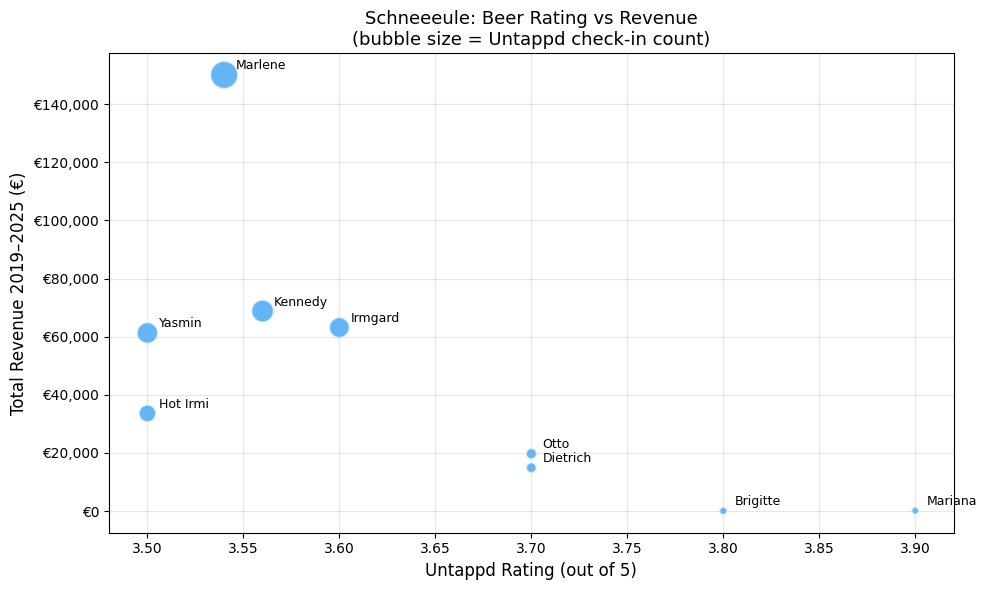

✅ Chart saved: output/rating_vs_revenue.png


In [28]:
# ── UNTAPPD RATINGS INTEGRATION ──────────────────────────────────────────────
# Ratings sourced manually from untappd.com (Feb 2026) - API requires paid plan
import os
os.chdir(r"C:\Users\erikr\Documents\beer-sales-analysis")
untappd_ratings = {
    "Marlene":   {"rating": 3.54, "checkins": 8036},
    "Kennedy":   {"rating": 3.56, "checkins": 5275},
    "Yasmin":    {"rating": 3.50, "checkins": 4678},
    "Irmgard":   {"rating": 3.60, "checkins": 4381},
    "Hot Irmi":  {"rating": 3.50, "checkins": 3145},
    "Otto":      {"rating": 3.70, "checkins": 1240},
    "Dietrich":  {"rating": 3.70, "checkins": 1145},
    "Brigitte":  {"rating": 3.80, "checkins":  651},
    "Mariana":   {"rating": 3.90, "checkins":  597},
}

def get_untappd_data(product_name):
    for beer, data in untappd_ratings.items():
        if beer.lower() in product_name.lower():
            return data["rating"], data["checkins"]
    return None, None

df["untappd_rating"] = df["bezeichnung"].apply(lambda x: get_untappd_data(x)[0])
df["untappd_checkins"] = df["bezeichnung"].apply(lambda x: get_untappd_data(x)[1])

# ── REVENUE vs RATING SUMMARY ─────────────────────────────────────────────────
rating_revenue = (
    df[df["untappd_rating"].notna()]
    .groupby(["bezeichnung", "untappd_rating", "untappd_checkins"])["gesamt_eur"]
    .sum()
    .reset_index()
    .rename(columns={"gesamt_eur": "total_revenue_eur"})
    .sort_values("total_revenue_eur", ascending=False)
)

# Extract base beer name for cleaner labels
rating_revenue["beer"] = rating_revenue["bezeichnung"].apply(
    lambda x: next((b for b in untappd_ratings if b.lower() in x.lower()), x)
)

# Collapse variants (Retail, Export, Keykeg) into one row per beer
rating_summary = (
    rating_revenue.groupby(["beer", "untappd_rating", "untappd_checkins"])["total_revenue_eur"]
    .sum()
    .reset_index()
    .sort_values("total_revenue_eur", ascending=False)
)

print(rating_summary.to_string(index=False))

# ── CHART: RATING vs REVENUE SCATTER ─────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    rating_summary["untappd_rating"],
    rating_summary["total_revenue_eur"],
    s=rating_summary["untappd_checkins"] / 20,  # bubble size = popularity
    alpha=0.7,
    color="#2196F3",
    edgecolors="white",
    linewidth=1.5
)

for _, row in rating_summary.iterrows():
    ax.annotate(
        row["beer"],
        (row["untappd_rating"], row["total_revenue_eur"]),
        textcoords="offset points", xytext=(8, 4), fontsize=9
    )

ax.set_xlabel("Untappd Rating (out of 5)", fontsize=12)
ax.set_ylabel("Total Revenue 2019–2025 (€)", fontsize=12)
ax.set_title("Schneeeule: Beer Rating vs Revenue\n(bubble size = Untappd check-in count)", fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output/rating_vs_revenue.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved: output/rating_vs_revenue.png")